In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


In [6]:
df=pd.read_csv(r"C:\Users\RAJDEEP\Downloads\Ridge+Lassso+Elastic+Regression+Practicals\Ridge Lassso Elastic Regression Practicals\Algerian_forest_fires_dataset_UPDATE.csv",header=1)

In [48]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
 14  Region       246 non-null    int64
dtypes: int64(1), str(14)
memory usage: 40.1 KB


In [50]:
#data cleaning
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1


In [82]:
df.loc[:122,'Region']=0
df.loc[122:,'Region']=1
ddf=df

In [83]:
ddf[['Region']]=ddf[['Region']].astype(int)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [84]:
# remove the Null values
ddf=ddf.dropna().reset_index(drop=True)

In [85]:
ddf.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [86]:
ddf.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [87]:
ddf=ddf.drop(122).reset_index(drop=True)

In [88]:
ddf.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [89]:
ddf.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [90]:
#removing the null val
ddf=ddf.drop(122).reset_index(drop=True)

In [91]:
ddf.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,02,06,2012,30,73,13,4,55.7,2.7,7.8,0.6,2.9,0.2,not fire,1


In [92]:
#removing the null val
ddf=ddf.drop(122).reset_index(drop=True)

In [93]:
ddf.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,03,06,2012,29,80,14,2,48.7,2.2,7.6,0.3,2.6,0.1,not fire,1


In [94]:
ddf.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

In [95]:
##fix space in col name
ddf.columns=ddf.columns.str.strip()

In [111]:
#changes the required columns as int data type
ddf[['month','day','year','Temperature','RH','Ws']].astype(int)

,month,day,year,Temperature,RH,Ws
0,6,1,2012,29,57,18
1,6,2,2012,29,61,13
2,6,3,2012,26,82,22
3,6,4,2012,25,89,13
4,6,5,2012,27,77,16
...,...,...,...,...,...,...
236,9,26,2012,30,65,14
237,9,27,2012,28,87,15
238,9,28,2012,27,87,29
239,9,29,2012,24,54,18


In [112]:
#changing the other col to float 
object=[features for features in ddf.columns if ddf[features].dtypes=='O']

In [113]:
for i in object:
    if i!= 'Classes':
        ddf[i]=ddf[i].astype(float)

In [114]:
ddf.info()

<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          241 non-null    str  
 1   month        241 non-null    str  
 2   year         241 non-null    str  
 3   Temperature  241 non-null    str  
 4   RH           241 non-null    str  
 5   Ws           241 non-null    str  
 6   Rain         241 non-null    str  
 7   FFMC         241 non-null    str  
 8   DMC          241 non-null    str  
 9   DC           241 non-null    str  
 10  ISI          241 non-null    str  
 11  BUI          241 non-null    str  
 12  FWI          241 non-null    str  
 13  Classes      241 non-null    str  
 14  Region       241 non-null    int64
dtypes: int64(1), str(14)
memory usage: 39.3 KB


In [115]:
#eda
ddf.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
#drop the features
df_copy=ddf.drop(['day','month','year'],axis=1)

In [131]:
df_copy['Classes'].astype(str)

0      1
1      1
2      1
3      1
4      1
      ..
236    1
237    1
238    1
239    1
240    1
Name: Classes, Length: 241, dtype: str

In [132]:
#encoding of the categories in classes
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

AttributeError: Can only use .str accessor with string values, not integer

In [133]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,1,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,1,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,1,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,1,0


In [134]:
df_copy['Classes'].value_counts()

Classes
1    239
0      2
Name: count, dtype: int64

In [136]:
df_copy.info()


<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Temperature  241 non-null    str  
 1   RH           241 non-null    str  
 2   Ws           241 non-null    str  
 3   Rain         241 non-null    str  
 4   FFMC         241 non-null    str  
 5   DMC          241 non-null    str  
 6   DC           241 non-null    str  
 7   ISI          241 non-null    str  
 8   BUI          241 non-null    str  
 9   FWI          241 non-null    str  
 10  Classes      241 non-null    int64
 11  Region       241 non-null    int64
dtypes: int64(2), str(10)
memory usage: 29.6 KB


In [140]:
plt.style.use('sns')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

OSError: 'sns' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [150]:
#percentage for pie chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100

([<matplotlib.patches.Wedge at 0x2a318aef0e0>,
 [Text(-1.0996261882544294, 0.028674834001866396, 'Fire'),
  Text(1.0996261907612588, -0.028674737869487942, 'Not Fire')])

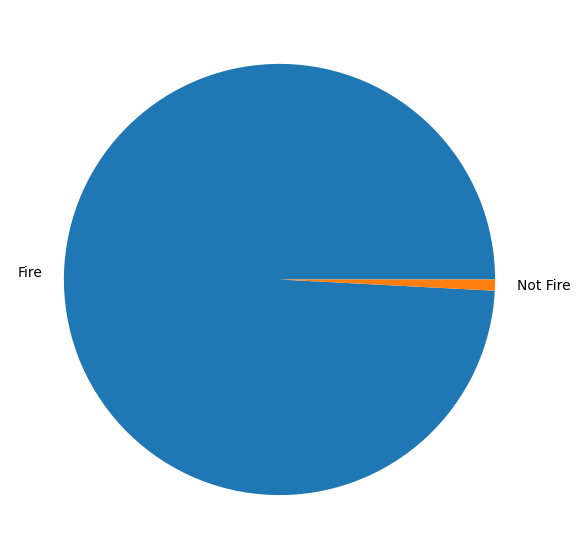

In [151]:
#plotting 
classlabels=['Fire',"Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels)


In [152]:
#corelation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651184,-0.288538,-0.324519,0.679353,0.485406,0.375432,0.604182,0.459374,0.566649,0.180338,0.273554
RH,-0.651184,1.000000,0.251609,0.219067,-0.643718,-0.405444,-0.223201,-0.685228,-0.350446,-0.578951,-0.129787,-0.410789
Ws,-0.288538,0.251609,1.000000,0.179167,-0.182322,-0.009466,0.072004,-0.000320,0.023004,0.024420,-0.080965,-0.173839
Rain,-0.324519,0.219067,0.179167,1.000000,-0.541693,-0.285066,-0.294782,-0.344192,-0.296227,-0.321227,-0.581926,-0.047080
FFMC,0.679353,-0.643718,-0.182322,-0.541693,1.000000,0.599438,0.502847,0.737525,0.587699,0.688538,0.234527,0.237933
DMC,0.485406,-0.405444,-0.009466,-0.285066,0.599438,1.000000,0.875084,0.677847,0.982107,0.874943,0.074553,0.201872
DC,0.375432,-0.223201,0.072004,-0.294782,0.502847,0.875084,1.000000,0.505104,0.941620,0.737783,0.080548,-0.072004
ISI,0.604182,-0.685228,-0.000320,-0.344192,0.737525,0.677847,0.505104,1.000000,0.641194,0.922326,0.098786,0.273803
BUI,0.459374,-0.350446,0.023004,-0.296227,0.587699,0.982107,0.941620,0.641194,1.000000,0.856918,0.077975,0.098330
FWI,0.566649,-0.578951,0.024420,-0.321227,0.688538,0.874943,0.737783,0.922326,0.856918,1.000000,0.085474,0.206362


<Axes: >

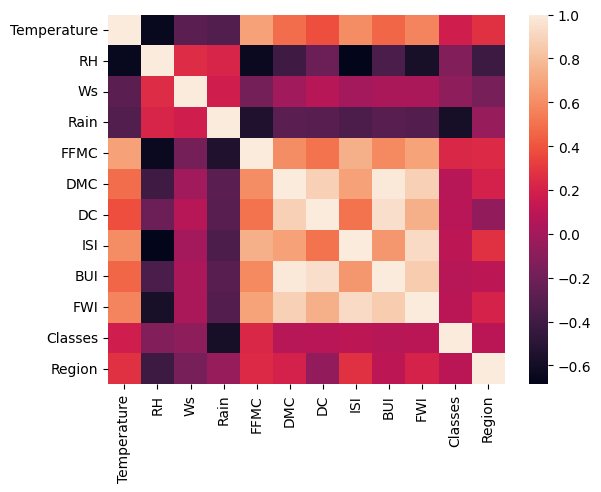

In [157]:
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

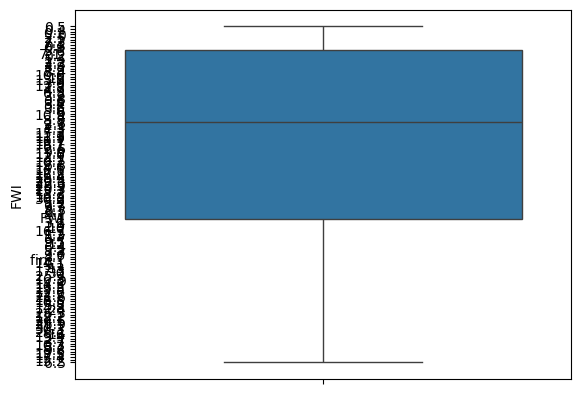

In [159]:
#boxplots

sns.boxplot(df["FWI"])

In [160]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,1,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,1,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,1,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,1,0


In [164]:
#encoding of the categories in classes
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),'not fire','fire')

AttributeError: Can only use .str accessor with string values, not integer

ValueError: Could not interpret value `Classes` for `hue`. An entry with this name does not appear in `data`.

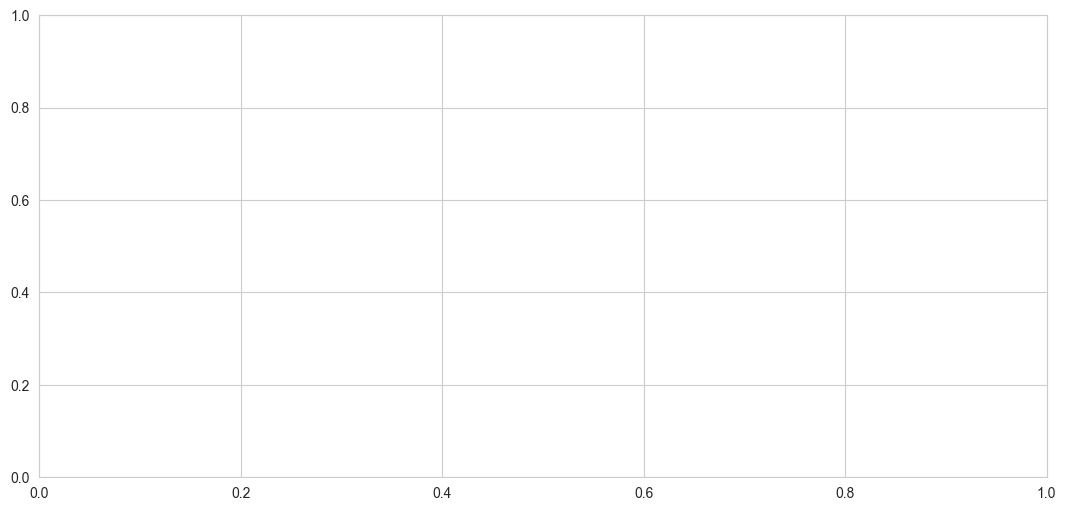

In [ ]:
#monthly fire analysis
dftemp=df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel('number of fires')
plt.xlabel('months')
plt.title('fire  analysis of sidi -bel region')

In [ ]:
dftemp=df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel('number of fires')
plt.xlabel('months')
plt.title('fire  analysis of birija    region')